# Exploring the Radioactive Decay Chain of $^{212}\mathrm{Pb}$  by Plotting the Concentration Change Over Time

**Ziyu Guo, 230296484, Department of Physics and Astronomy, Queen Mary University of London, Mile End Road, E1 4NS, United Kingdom**

# Introduction

**Abstract**

In nature, the radioactive isotope of an element constantly releases energies through radioactive decay. They always emit into a more stable atom and radiation: Alpha, beta or gamma decay. One of the most important properties of any radioactive material, as follows from this analysis, is its half-life. This refers to the time required for half of a given number of radioactive atoms to decay and is inversely related to the isotope's decay constant, λ.[[1](https://en.wikipedia.org/wiki/Decay_chain#History)] Because the radioactive isotopes cannot decay into a stable isotope in one single step, the decay chain is used to describe their decay process until they reach the ground status.

**Aim of The Project**

In this project, I am going to explore the radioactive decay chain of $^{212}\mathrm{Pb}$. Its decay chain is divided into 5 small steps with the given rate constants. A good way to track their change during the decay process is by measuring the concentration of different isotopes as time passes. To identify how the concentration of each step changes, the first-order differential equation and rate constants can be used. Also, I need to plot a graph of the change of the concentration as a function of time until all isotopes reach a steady state. At the end, use the approximate expression equation of $^{212}\mathrm{Pb}$ concentration as a function of time to plot a graph and compare it with the theoretical values.

**Ordinary Differential Equation**

Each small step of decay can be expressed as a first order differential equation of concentration and their rate constants. I choose to use the built-in method `solve_ivp` to solve the ordinary differential equation. The built-in method is way faster to solve the ordinary differential equations and numerical error can be controlled by the relative tolerance (rtol) and absolute tolerance (atol).

**Graph Ploting**

Plot the concentration change for all isotopes as time pass by. Also, plot the $^{212}\mathrm{Pb}$ of the approximate expression equation and compare it with the numerical integration one. To verify the occupation of the concentration of each isotope, plot the graph of the total concnetration, which should always be 1 as time increase.

# Method

For this report, since all $^{212}\mathrm{Pb}$ turn into $^{208}\mathrm{Pb}$, the complete radioactive decay chain invcolves 5 steps and their rate constants, k:

\begin{align}
^{212}\mathrm{Pb}  →  ^{212}\mathrm{Bi} + β^- \,   \quad   k_1 =  1.816 \times 10^{-5} \mathrm{s}^{-1}\\
^{212}\mathrm{Bi}  → ^{208}\mathrm{Tl} + α \,   \quad   k_2 = 6.931 \times 10^{-5} \mathrm{s}^{-1}\\
^{212}\mathrm{Bi} → ^{212}\mathrm{Po} + β^-\,  \quad   k_3 = 1.232 \times 10^{-4} \mathrm{s}^{-1}\\
^{208}\mathrm{Tl} → ^{208}\mathrm{Pb} + β^-\,  \quad   k_4 = 3.851 \times 10^{-3} \mathrm{s}^{-1}\\
^{212}\mathrm{Po} → ^{208}\mathrm{Pb} + α\,  \quad   k_5 = 2.310\mathrm{s}^{-1}\,   \quad   \quad   \quad   \\
\end{align}

The expression of the half-life is:
$N = N_0 e^{-λt}$

And the relationship between the half-life and the rate constant is:
$k = \frac{ln2}{half-life}$

I took the half-life datas of these 5 steps from Laboratoire National Henri Becquerel (LNHB) [[2](http://www.lnhb.fr/home/nuclear-data/nuclear-data-table/)] to calculate the rate constants. Although the calculated values of k are slightly different from those given values of k, these values should provide a similar trend of the graph to the given values one. 

***1. Let me start with solving the ordinary differential equations:***

Because i need to solve maths problems and plot the graphs, import numpy, scipy and matplotlib.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Based on the decay of 5 isotopes, the first order differential equations with their concentrations and the rate constants k can be expressed as:

\begin{align}
\frac{d[^{212}\mathrm{Pb}]}{dt} = {- k_1} [^{212}\mathrm{Pb}]\\
\frac{d[^{212}\mathrm{Bi}]}{dt} = + {k_1} [^{212}\mathrm{Pb}] - {k_2}[^{212}\mathrm{Bi}] - {k_3} [^{212}\mathrm{Bi}]\\
\frac{d[^{208}\mathrm{Tl}]}{dt} = +{k_2} [^{212}\mathrm{Bi}] - {k_4} [^{208}\mathrm{Tl}]\\
\frac{d[^{212}\mathrm{Po}]}{dt} = +{k_3} [^{212}\mathrm{Bi}] - {k_5} [^{212}\mathrm{Po}]\\
\frac{d[^{208}\mathrm{Pb}]}{dt} = +{k_4} [^{208}\mathrm{Tl}] + {k_5} [^{212}\mathrm{Po}]\\
\end{align}

The concentration of $^{212}\mathrm{Pb}$ can be expressed as $[^{212}\mathrm{Pb}]$

***To solve the ordinary differential equations, define the values of k first, then build up a function called RDC to describe the ODEs.***

In [2]:
k1 = 1.816e-5
k2 = 6.931e-5
k3 = 1.232e-4
k4 = 3.851e-3
k5 = 2.310

def RDC(t, y):
    Pb212, Bi212, Po212, Tl208, Pb208 = y
    dPb212 = -k1 * Pb212
    dBi212 = (k1 * Pb212) - (k2 * Bi212) - (k3 * Bi212)
    dTl208 = (k2 * Bi212) - (k4 * Tl208)
    dPo212 = (k3 * Bi212) - (k5 * Po212)
    dPb208 = (k4 * Tl208) + (k5 * Po212)
    
    return [dPb212, dBi212, dPo212, dTl208, dPb208]

***2. Now solve the ODEs:***

To solve this numerical integration, I choose to use `solve_ivp`. The initial condition (t = 0) is needed and only $^{212}{Pb}$ isotope is avaialable while all other isotopes are 0. Therefore I set the concentration of $^{212}{Pb}$ as 1 and all otheres are 0. 

The built-in method need us to set the time range of this function. This span should be long enough that the concentration of all isotopes could reach a steady state. Then plot the graph of concentrations as a function of time. I have tried several times and I found that the graph cannot reach the stead state with $10^{5}$, $10^{4}$ or smaller values as `t_span`. Let me plot the graph with the range from 0 to $10^{6}$ seconds first.


In [3]:
initial_conditions = [1.0, 0.0, 0.0, 0.0, 0.0]

t_span = (0, 1e6)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

solution = solve_ivp(RDC, t_span, initial_conditions, t_eval=t_eval, method='BDF')

t = solution.t
Pb212, Bi212, Tl208, Po212, Pb208 = solution.y

I set up 1000 points within this range, which could make the graph looks more smooth. When using `solve_ivp` to solve the ordinary differential equations, the bracket should contain: The function we defined, the interval (`t_span`), initial conditions, t_eval and backward differentiation formula ("BDF").


***3. Apply the Appoximate Expression:***

The final concentration of the  $^{208}\mathrm{Pb}$ isotope can be expressed as a function of its initial concentration as time and rate constant:

\begin{align}
{[^{208}\mathrm{Pb}]}{(t)} = {[^{212}\mathrm{Pb}]}{(t = 0)}{(1 - {e^{-k_1}{t}})}
\end{align}

This expression is an approximate expression, '(t = 0)' means the concentration of $^{208}\mathrm{Pb}$ is at the initial condition.

***In this case, such equation can be print out as:***

In [4]:
Pb208_approx = initial_conditions[0] * (1 - np.exp(-k1 * t))

***4. Plot the Graph:***

I set the concentration as the y-axis, and time as the x-axis. Because the time range of the x-axis is 1e6 with the unit 'second', it is too big to understand. I convert the unit of x-axis into 'hours' by dividing 3600 seconds. This would make the diagram more readable and more visualised. I plot the graph for the concentration of all isotopes as solid lines, their trends can be read easily. Also, plot the graph of the approximate expression of $^{208}\mathrm{Pb}$ and make it a 'dotted line'. Compare the numerical value of $^{208}\mathrm{Pb}$ (solid line) and its approximate expression value (dotted line).

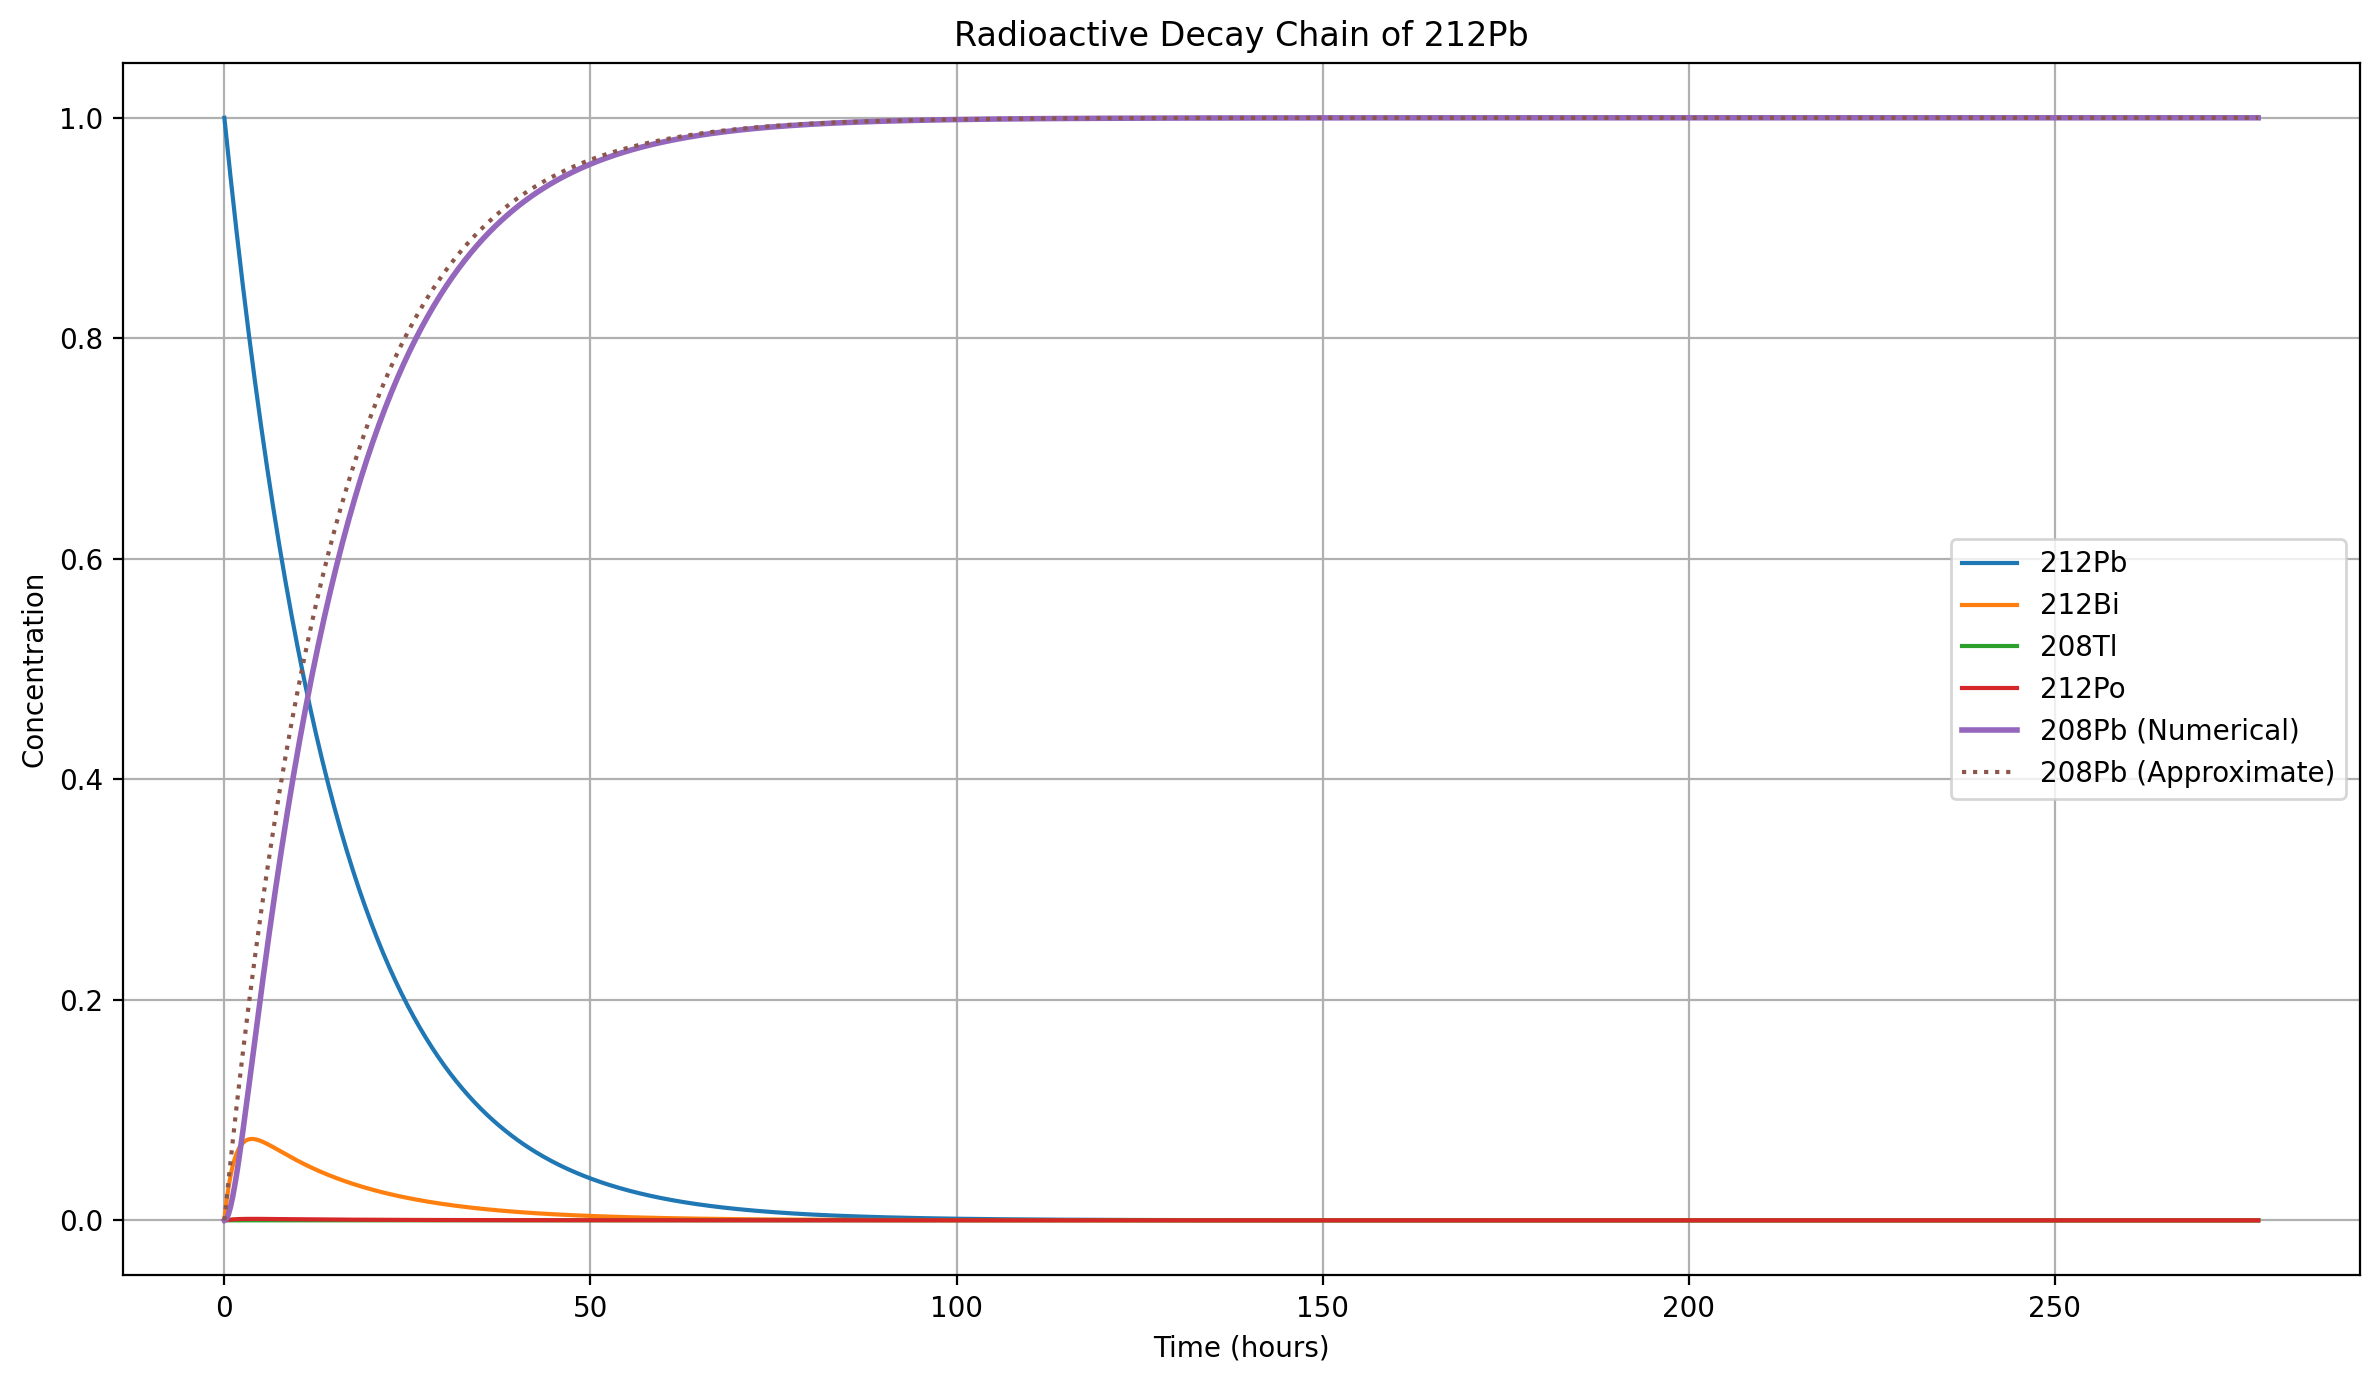

In [5]:
plt.figure()
plt.plot(t / 3600, Pb212, label=r"212Pb")
plt.plot(t / 3600, Bi212, label=r"212Bi")
plt.plot(t / 3600, Tl208, label=r"208Tl")
plt.plot(t / 3600, Po212, label=r"212Po")
plt.plot(t / 3600, Pb208, label=r"208Pb (Numerical)", linewidth=2)
plt.plot(t / 3600, Pb208_approx, label=r"208Pb (Approximate)", linestyle='dotted')

plt.xlabel("Time (hours)")
plt.ylabel("Concentration")
plt.title("Radioactive Decay Chain of 212Pb")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


***5. Check the Conservation of the Concentration:***

Theoredically, the sum of total concentration of all isotopes should always equal to 1. To verify the conservation of the concentration, I also plot the graph of the change of the sum concentration.

In [6]:
sum_concentration = Pb212 + Bi212 + Tl208 + Po212 + Pb208

At the same time, there is a large blank area on the right hand side. I reset the range of the x-axis, which is the time, to make the plot look better. I reset the t_span to the range from 0 to 4e5.

***Therefore, this is the new plot:***

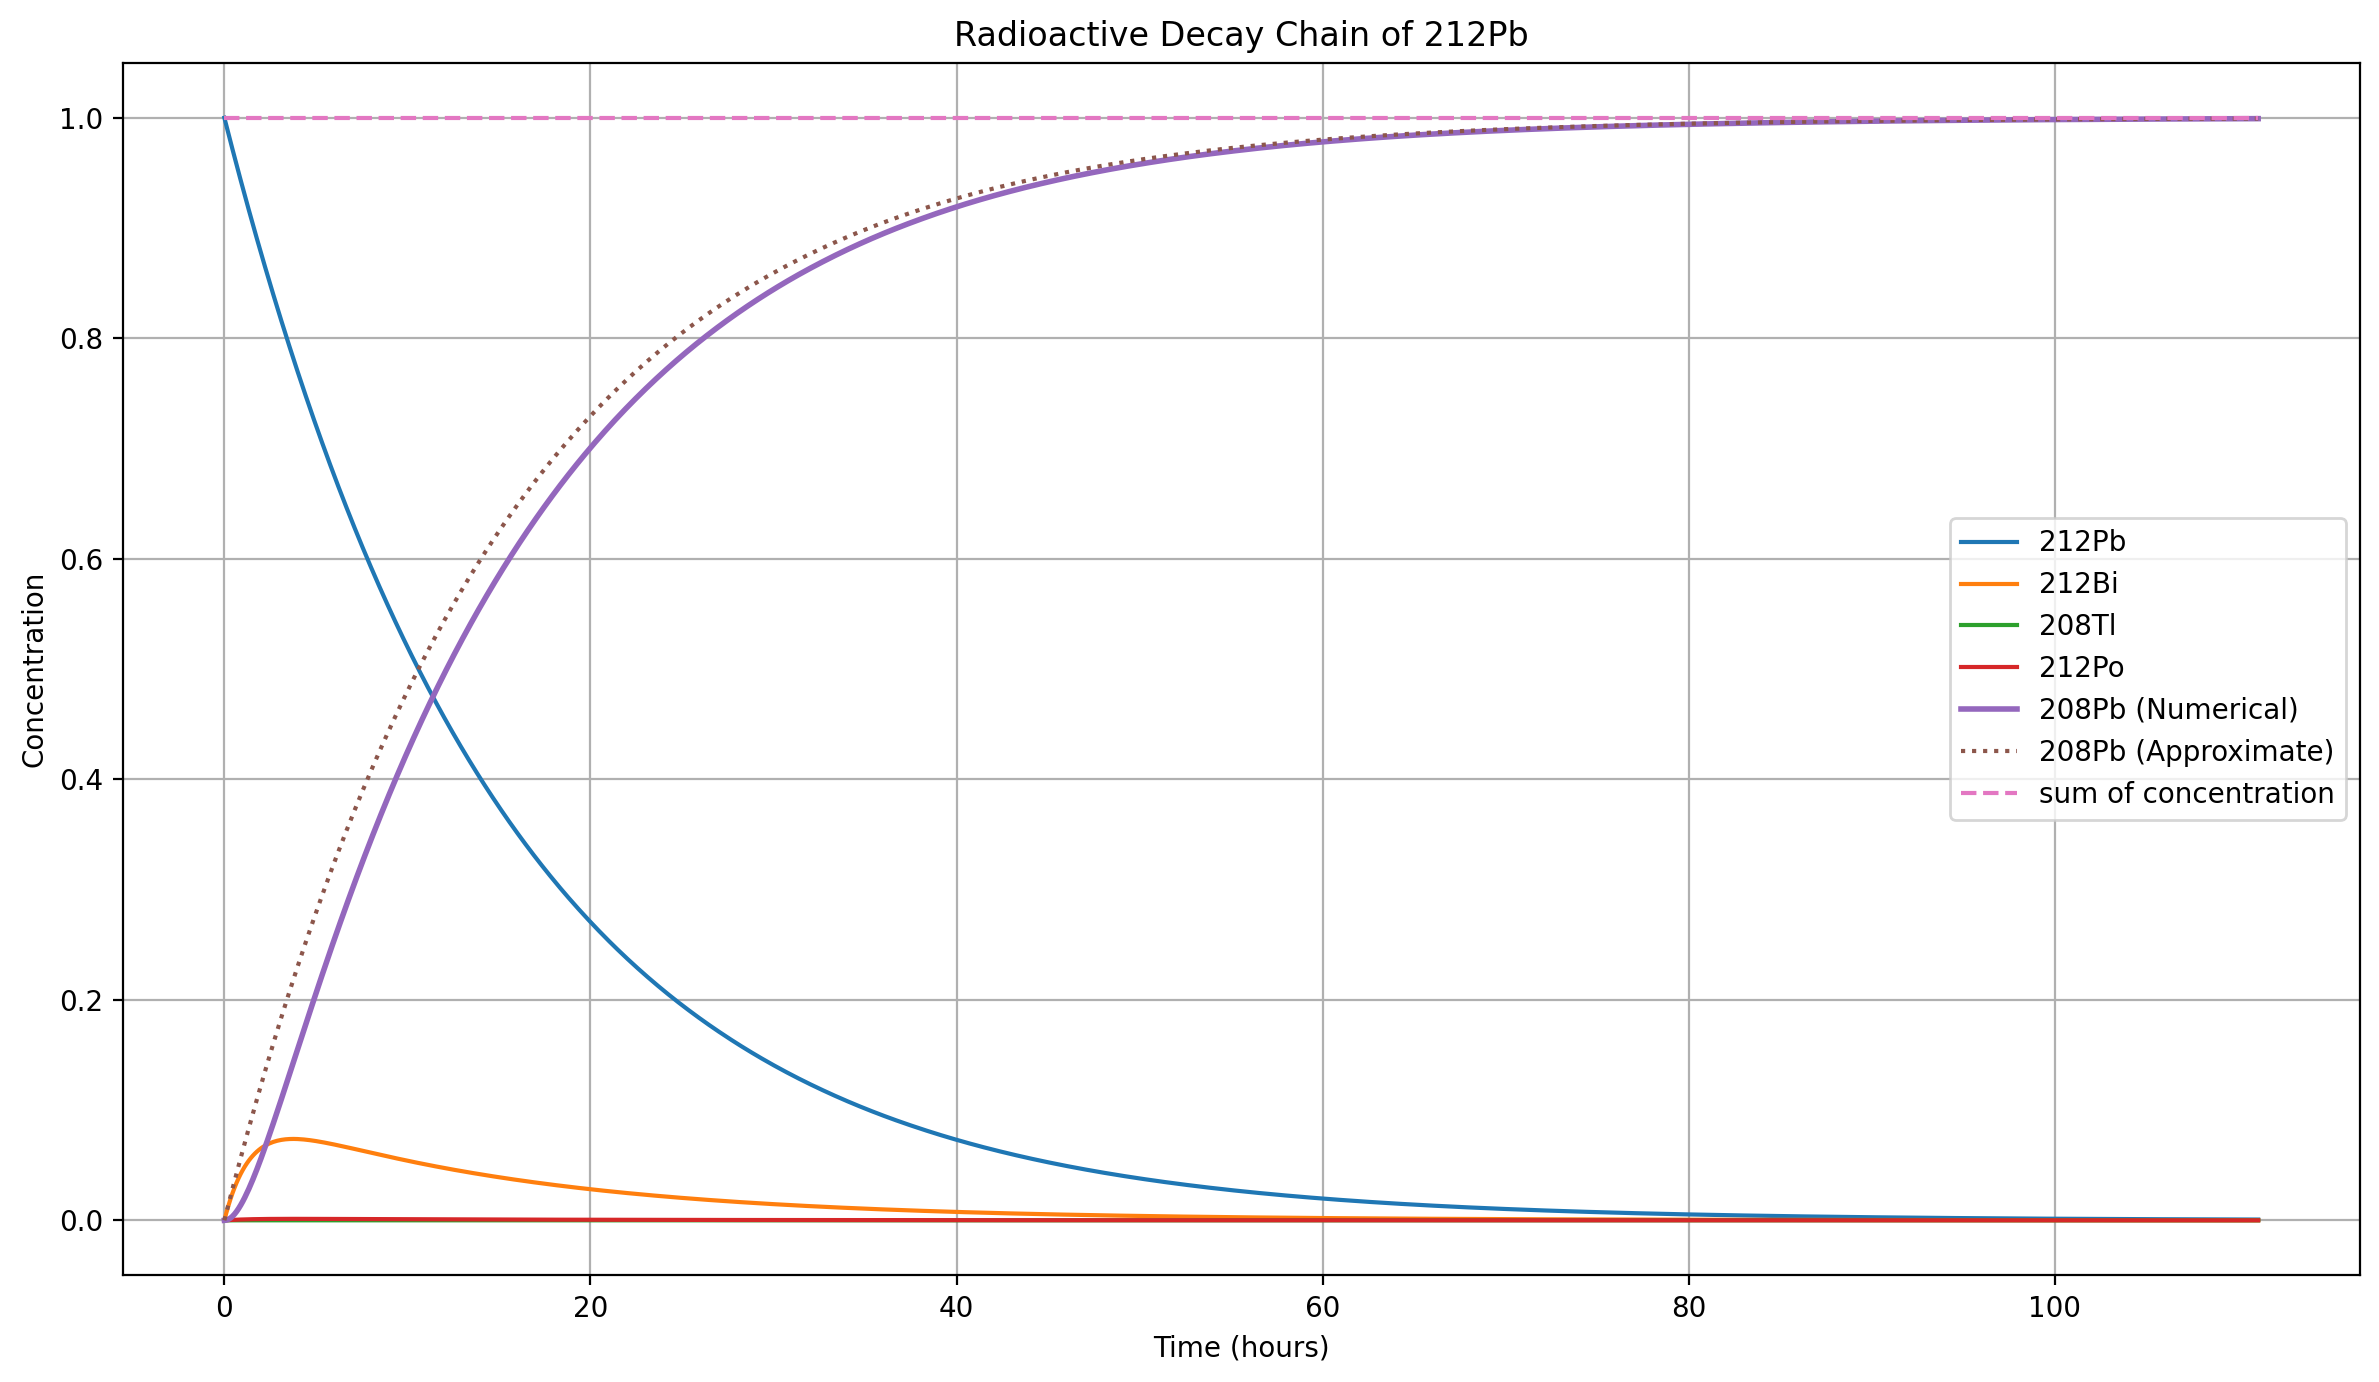

In [7]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

k1 = 1.816e-5
k2 = 6.931e-5
k3 = 1.232e-4
k4 = 3.851e-3
k5 = 2.310

def RDC(t, y):
    Pb212, Bi212, Po212, Tl208, Pb208 = y
    dPb212 = -k1 * Pb212
    dBi212 = (k1 * Pb212) - (k2 * Bi212) - (k3 * Bi212)
    dTl208 = (k2 * Bi212) - (k4 * Tl208)
    dPo212 = (k3 * Bi212) - (k5 * Po212)
    dPb208 = (k4 * Tl208) + (k5 * Po212)
    
    return [dPb212, dBi212, dPo212, dTl208, dPb208]

initial_conditions = [1.0, 0.0, 0.0, 0.0, 0.0]

t_span = (0, 4e5)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

solution = solve_ivp(RDC, t_span, initial_conditions, t_eval=t_eval, method='BDF')

t = solution.t
Pb212, Bi212, Tl208, Po212, Pb208 = solution.y

Pb208_approx = initial_conditions[0] * (1 - np.exp(-k1 * t))

sum_concentration = Pb212 + Bi212 + Tl208 + Po212 + Pb208

plt.figure()
plt.plot(t / 3600, Pb212, label=r"212Pb")
plt.plot(t / 3600, Bi212, label=r"212Bi")
plt.plot(t / 3600, Tl208, label=r"208Tl")
plt.plot(t / 3600, Po212, label=r"212Po")
plt.plot(t / 3600, Pb208, label=r"208Pb (Numerical)", linewidth=2)
plt.plot(t / 3600, Pb208_approx, label=r"208Pb (Approximate)", linestyle='dotted')
plt.plot(t / 3600, sum_concentration, label=r"sum of concentration", linestyle='--')

plt.xlabel("Time (hours)")
plt.ylabel("Concentration")
plt.title("Radioactive Decay Chain of 212Pb")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


Now, this plot could effectively illustrate the changes in the concentrations of each isotopes, and their relationship can be clearly observed.

# Result
***Characteristics of the Plot***

From the plot above, all isotopes show a linear change as time passes.

For $^{212}\mathrm{Pb}$, it shows a line of exponential decay. Its concentration started from 1 and decreased constantly as time increased. This trend obeys the radioactive decay law and its concentration reached 0 in the end.

$^{212}\mathrm{Bi}$ is the direct product of this radioactive decay chain. From the plot, the concentration of $^{212}\mathrm{Bi}$ first increased until a peak and gradually decreased. The reason for this phenomenon is that, although $^{212}\mathrm{Bi}$ isotopes are increasing during this process, it is continuously decay into other isotopes at the same time.

For the radioactive decay of $^{212}\mathrm{Bi}$, there are two branches of products: $^{208}\mathrm{Tl}$ and $^{212}\mathrm{Po}$. Their concentration cannot be easily noticed from this plot because their concentration is much lower. 

 $^{208}\mathrm{Pb}$ is the final product of this radioactivce decay chain, and all isotopes decay into $^{212}\mathrm{Pb}$ and become stable. Its concentration increases and the gradient becomes smaller as time passes by until all isotopes turn into  $^{208}\mathrm{Pb}$. There are two lines that describe the concentration of  $^{208}\mathrm{Pb}$, one is the approximate value and the other one is numerical. These two lines coincide at last because both of these two methods can gain the same final concentration of  $^{212}\mathrm{Pb}$. The difference between them at the beginning is that the approximate value one ignores the middle steps of decays, it directly changes to  $^{212}\mathrm{Pb}$ particles. That also makes the line increase earlier.
 
The dashed line shows the sum of concentrations of all isotopes over time. From the plot, this line lies on a horizontal line, y = 1, during the whole process. This verifies the conservation law and shows that the plot is correct.

# Discussion
The previous plot is made by calculating the first ordinary differential equation through given rate constant values, k. To explore the stability and reliability, I choose to use the half-life of these isotopes to plot their concentration change as a function as time. I visited Laboratoire National Henri Becquerel (LNHB) and find their half-lifes:

\begin{align}
^{212}\mathrm{Pb} = 10.64 h\\
^{212}\mathrm{Bi} = 60.54 min\\
^{208}\mathrm{Tl} = 3.058 min\\
^{212}\mathrm{Po} = 300 \times {10}^{-9}s\\
\end{align}

Because the total decay chain is divided into 2 branches:
- $^{212}\mathrm{Pb}$ → $^{212}\mathrm{Bi}$ → $^{208}\mathrm{Tl}$ → $^{208}\mathrm{Pb}$
- $^{212}\mathrm{Pb}$ → $^{212}\mathrm{Bi}$ → $^{212}\mathrm{Po}$ → $^{208}\mathrm{Pb}$

***In the second step of decay, 64.07% of $^{212}\mathrm{Bi}$ isotope convert into β radiation and $^{212}\mathrm{Po}$, while 35.93% of $^{212}\mathrm{Bi}$ isotope convert into α ray and $^{208}\mathrm{Tl}$.***

With these values, we can calculate the rate constants with the formula $k = \frac{ln2}{half-life}$:

In [8]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

***Express the new rate constants through half-lives:***

In [9]:
hl_Pb212 = 10.64 * 3600
hl_Bi212 = 60.54 * 60
hl_Po212 = 300e-9
hl_Tl208 = 3.058 * 60

k1_new = np.log(2) / hl_Pb212
k2_new = np.log(2) / hl_Bi212
k3_new = 0.6407 * k2_new
k4_new = 0.3593 * k2_new
k5_new = np.log(2) / hl_Tl208

The method used to make the plot is quite similar to the previous one.

***Again, set up a new function to describe the ordinary differential equation:***

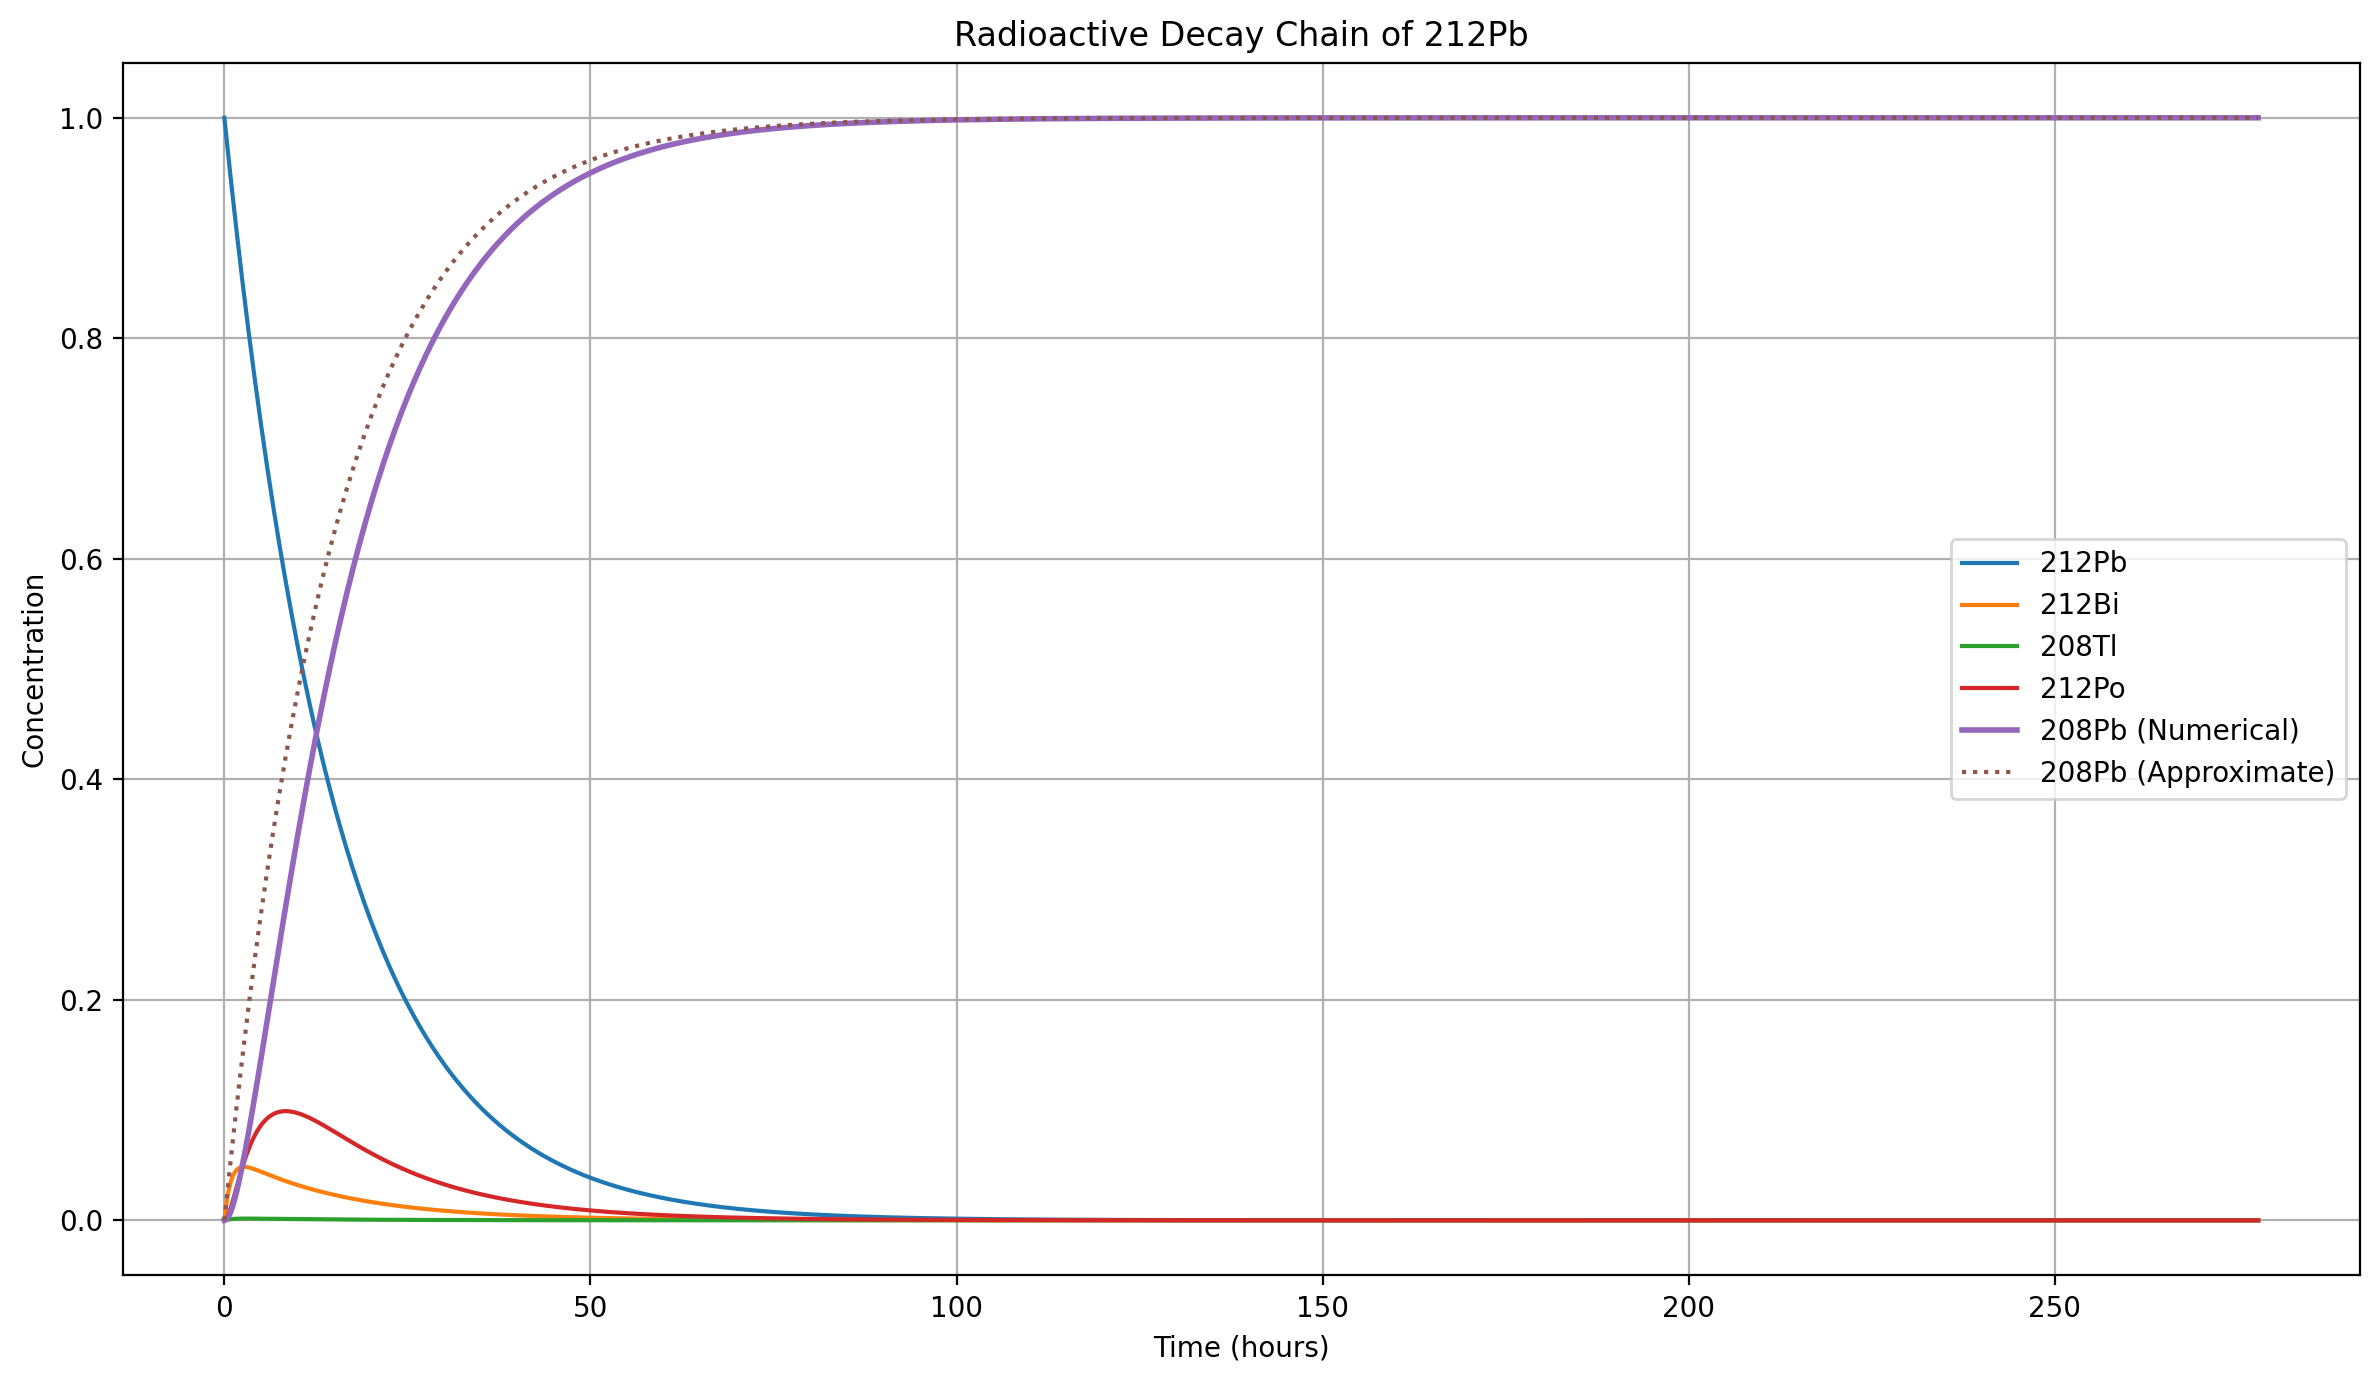

In [10]:
def RDC(t, y):
    Pb_212, Bi_212, Po_212, Tl_208, Pb_208 = y
    dPb_212 = -k1_new * Pb_212
    dBi_212 = (k1_new * Pb_212) - (k2_new * Bi_212) - (k3_new * Bi_212)
    dTl_208 = (k2_new * Bi_212) - (k4_new * Tl_208)
    dPo_212 = (k3_new * Bi_212) - (k5_new * Po_212)
    dPb_208 = (k4_new * Tl_208) + (k5_new * Po_212)
    
    return [dPb_212, dBi_212, dPo_212, dTl_208, dPb_208]

initial_conditions = [1.0, 0.0, 0.0, 0.0, 0.0]

t_span = (0, 1e6)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

solution = solve_ivp(RDC, t_span, initial_conditions, t_eval=t_eval, method='BDF')

t = solution.t
Pb_212, Bi_212, Tl_208, Po_212, Pb_208 = solution.y

Pb_208_approx = initial_conditions[0] * (1 - np.exp(-k1_new * t))

plt.figure()
plt.plot(t / 3600, Pb_212, label=r"212Pb")
plt.plot(t / 3600, Bi_212, label=r"212Bi")
plt.plot(t / 3600, Tl_208, label=r"208Tl")
plt.plot(t / 3600, Po_212, label=r"212Po")
plt.plot(t / 3600, Pb_208, label=r"208Pb (Numerical)", linewidth=2)
plt.plot(t / 3600, Pb_208_approx, label=r"208Pb (Approximate)", linestyle='dotted')

plt.xlabel("Time (hours)")
plt.ylabel("Concentration")
plt.title("Radioactive Decay Chain of 212Pb")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


From the new plot, those changes of the concentrations of differenc isotopes show a similar trend from the previous one. However, there are still some small differences.

***Improve the plot by changing its t_span, then add the line to show the sum of all concentrations, the new plot looks like this:***

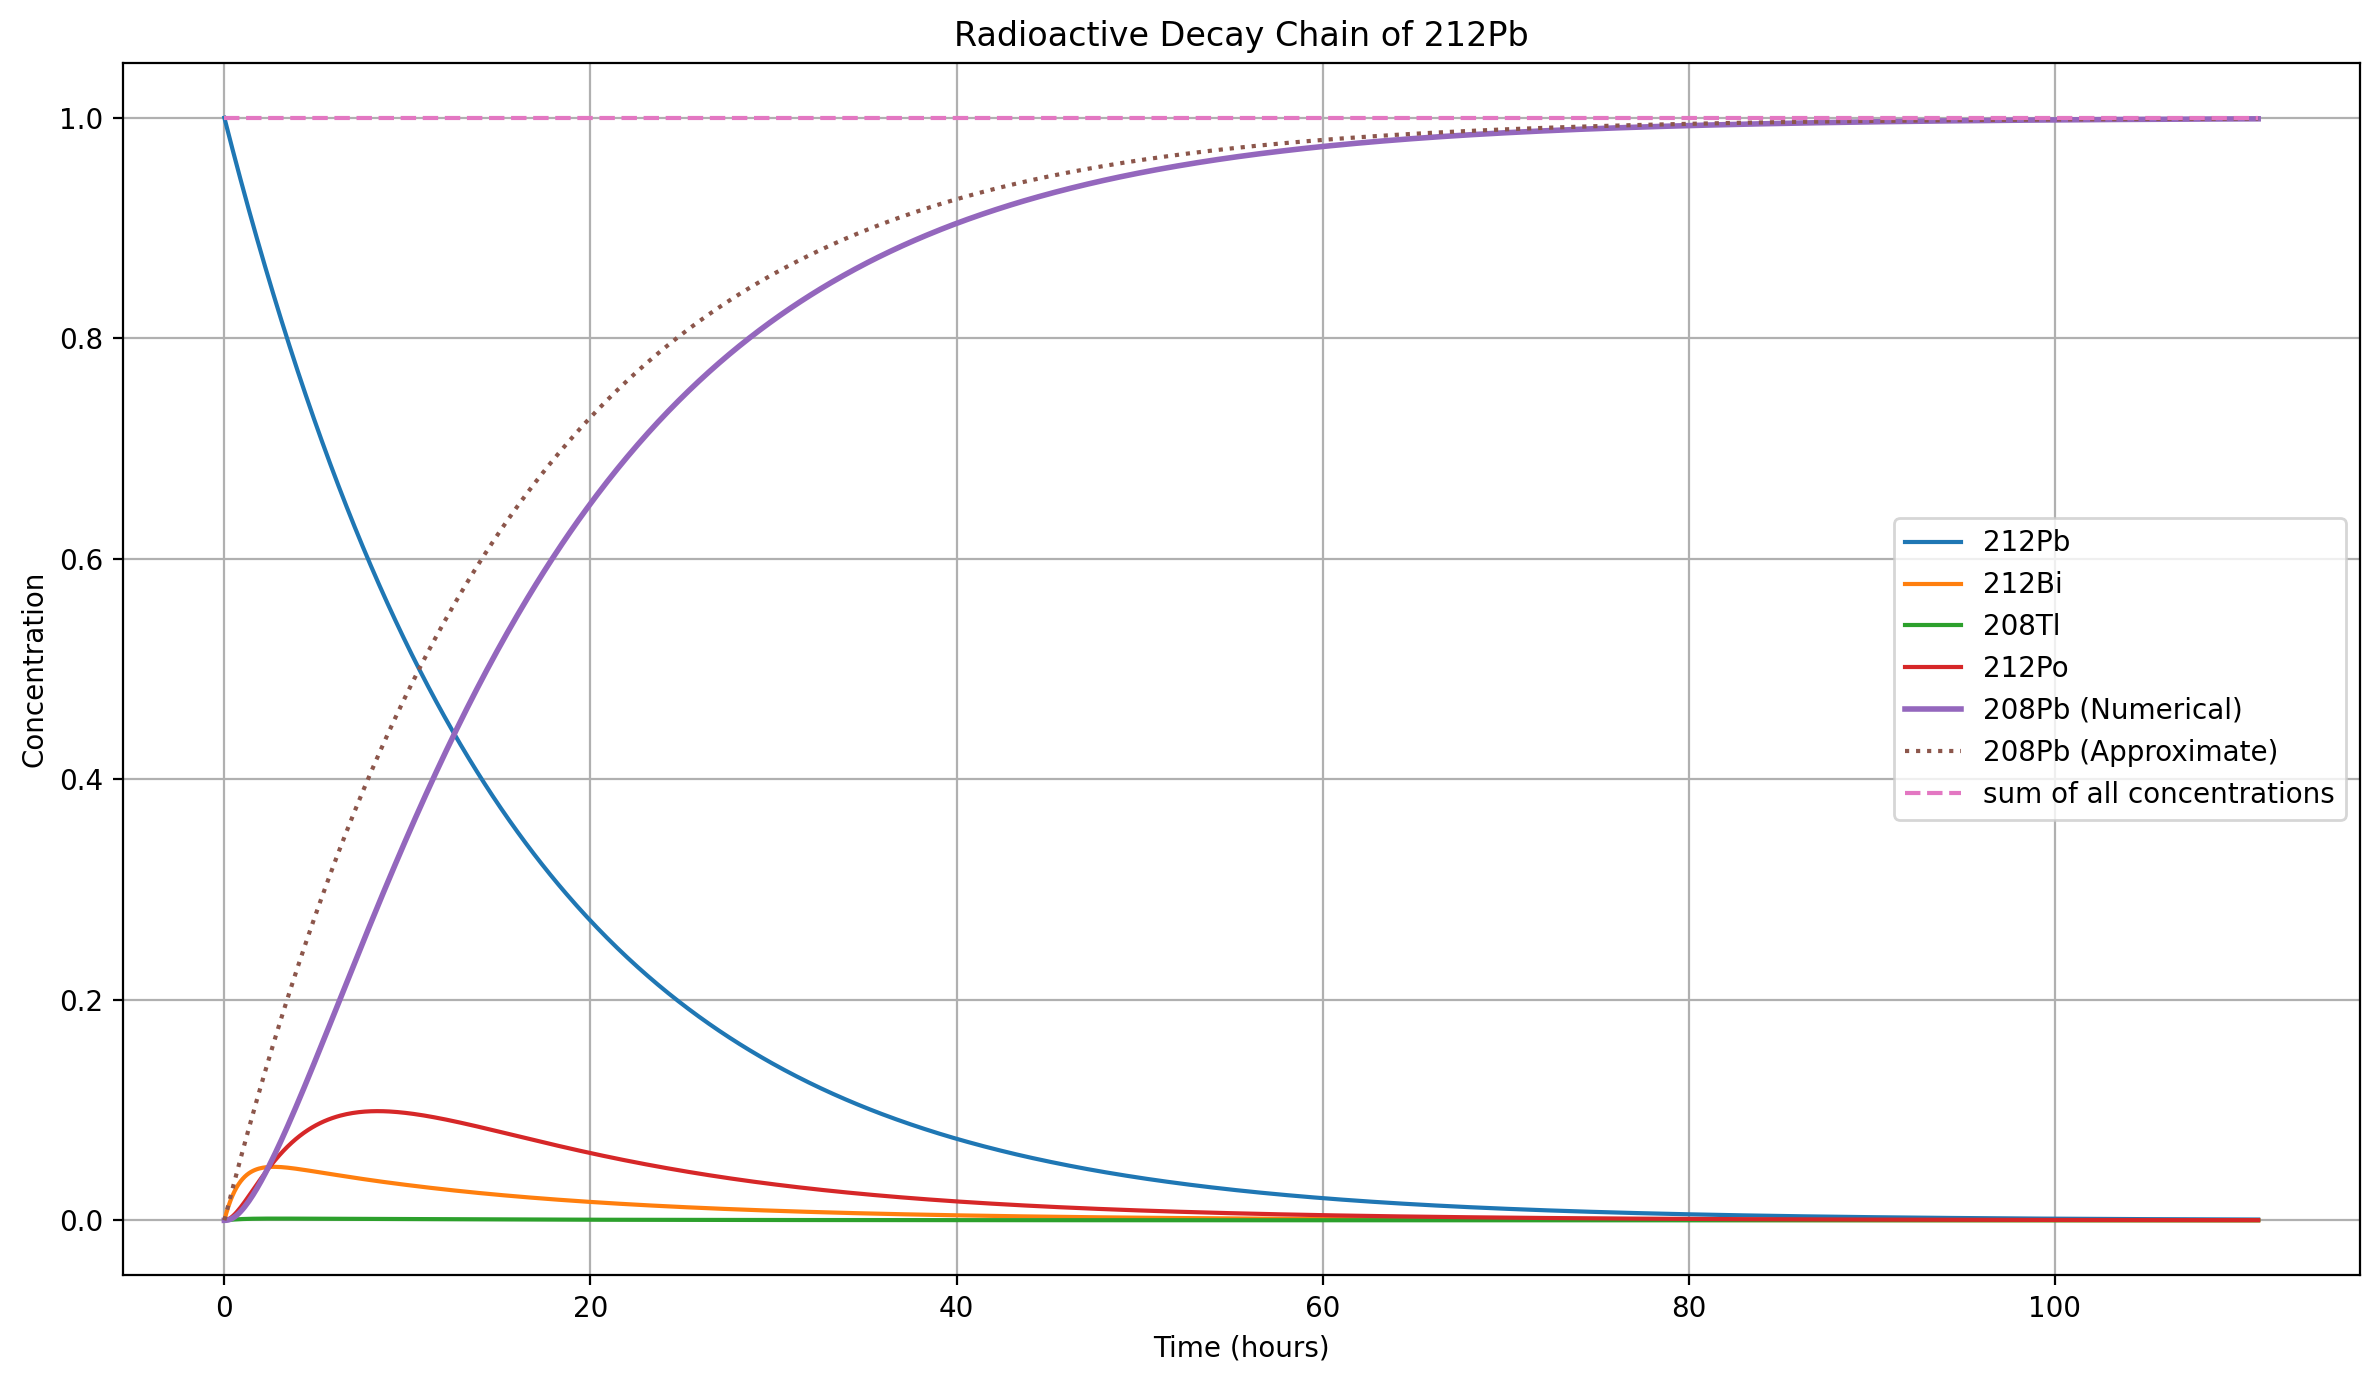

In [11]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

hl_Pb212 = 10.64 * 3600
hl_Bi212 = 60.54 * 60
hl_Po212 = 300e-9
hl_Tl208 = 3.058 * 60

k1_new = np.log(2) / hl_Pb212
k2_new = np.log(2) / hl_Bi212
k3_new = 0.6407 * k2_new
k4_new = 0.3593 * k2_new
k5_new = np.log(2) / hl_Tl208

def RDC(t, y):
    Pb_212, Bi_212, Po_212, Tl_208, Pb_208 = y
    dPb_212 = -k1_new * Pb_212
    dBi_212 = (k1_new * Pb_212) - (k2_new * Bi_212) - (k3_new * Bi_212)
    dTl_208 = (k2_new * Bi_212) - (k4_new * Tl_208)
    dPo_212 = (k3_new * Bi_212) - (k5_new * Po_212)
    dPb_208 = (k4_new * Tl_208) + (k5_new * Po_212)
    
    return [dPb_212, dBi_212, dPo_212, dTl_208, dPb_208]

initial_conditions = [1.0, 0.0, 0.0, 0.0, 0.0]

t_span = (0, 4e5)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

solution = solve_ivp(RDC, t_span, initial_conditions, t_eval=t_eval, method='BDF')

t = solution.t
Pb_212, Bi_212, Tl_208, Po_212, Pb_208 = solution.y

Pb_208_approx = initial_conditions[0] * (1 - np.exp(-k1_new * t))

sum_concentration = Pb_212 + Bi_212 + Tl_208 + Po_212 + Pb_208

plt.figure()
plt.plot(t / 3600, Pb_212, label=r"212Pb")
plt.plot(t / 3600, Bi_212, label=r"212Bi")
plt.plot(t / 3600, Tl_208, label=r"208Tl")
plt.plot(t / 3600, Po_212, label=r"212Po")
plt.plot(t / 3600, Pb_208, label=r"208Pb (Numerical)", linewidth=2)
plt.plot(t / 3600, Pb_208_approx, label=r"208Pb (Approximate)", linestyle='dotted')
plt.plot(t / 3600, sum_concentration, label=r"sum of all concentrations", linestyle='--')

plt.xlabel("Time (hours)")
plt.ylabel("Concentration")
plt.title("Radioactive Decay Chain of 212Pb")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


According to this new plot, we can see some obvious characteristics.

***Same Features:***

The overall trend of this radioactive decay chain is as same as the previous one.

The concentration line of $^{212}\mathrm{Pb}$ still shows a exponential decay line overtime, it reaches to 0 as its ground states.

***Difference:***

$^{212}\mathrm{Po}$ isotope shows a totally different trend. In the new plot, it increased at first, after reaching a peak, it gradually decrease and become to 0 in the end.

Compare with the initial plot, the gap between the approximate value of $^{208}\mathrm{Pb}$ and the numerical value of $^{208}\mathrm{Pb}$ is larger.

Such difference of the plot is caused by the difference of the ate constants. In the privious code, all 5 rate constants are seperate and independent. But in the second plot, the rate constant of $^{212}\mathrm{Po}$ and $^{208}\mathrm{Tl}$ are related with $^{212}\mathrm{Bi}$. It is because during the decay chain, 64.07% of $^{212}\mathrm{Bi}$ isotope decays into $^{212}\mathrm{Po}$ while 35.93% of $^{212}\mathrm{Bi}$ isotope decays into $^{208}\mathrm{Tl}$.



# Conclusion:
At the begining of this project, I choose to use given rate constants, k, from the *'Introduction to Scientific Computing Project topic possibilities'* as the first model to plot the graph. This graph illustrates the concentration change of various isotopes during an radioactive decay chain. This graph is more like an ideal graph because the rates of each isotopes are theoradical and fixed. Both the numerical integration line and the approximate integration line of $^{208}\mathrm{Pb}$ shows a good agreement in this process. The observed space between these two lines is because the approximate integration ignored the middle steps in the decay process.

In the second model I built, I calculated the rate constants using the experimentally half-lives of each isotopes. These datas are more based on the real environment conditions. The line of approximate integration and the numerical integration stay further might caused by the ratio of the branches. In my opinion, in reality, $^{212}\mathrm{Bi}$ should decay into $^{212}\mathrm{Po}$ and $^{208}\mathrm{Tl}$, then these two isotopes can decay to the final output, $^{208}\mathrm{Pb}$. This process may leads to a delay in the decay chain, and the numerical integration line shift more backward.

In conclusion, all these two sets of models provide a similar trend about the concentration change of the radioactive decay chain of $^{212}\mathrm{Pb}$. Both the numerical integration and the approximate integration can gain the final output, but the approximate integration is way faster.


# References:


[1] https://en.wikipedia.org/wiki/Decay_chain#History<br>
[2] http://www.lnhb.fr/home/nuclear-data/nuclear-data-table/